# MSA 2026 Phase 2 - Part 1

In [25]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Find all variables and understand them
In this section, we load the raw datasets and inspect their baseline properties, including the number of instances, features, data types, and initial statistical distributions.

### 1.1 Load chosen datasets from the datasets folder into your notebook and display the first ten instances.

In [26]:
# Load W store sales datasets
w_sales = pd.read_csv('datasets/W store sales/sales.csv')
w_features = pd.read_csv('datasets/W store sales/features.csv')
w_stores = pd.read_csv('datasets/W store sales/stores.csv')

# Load X store sales dataset (using latin1 encoding in case of special characters)
x_sales = pd.read_csv('datasets/X store sales/store_sales.csv', encoding='latin1')

# Display first ten instances
print("W Store Sales - First 10 instances:")
display(w_sales.head(10))

print("\nW Store Features - First 10 instances:")
display(w_features.head(10))

print("\nW Stores - First 10 instances:")
display(w_stores.head(10))

print("\nX Store Sales - First 10 instances:")
display(x_sales.head(10))

W Store Sales - First 10 instances:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False



W Store Features - First 10 instances:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False



W Stores - First 10 instances:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512



X Store Sales - First 10 instances:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
5,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
6,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
7,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
8,30,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
9,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


### 1.1.1 Inspect Number of Instances, Features, and Data Types
Understanding the raw shape and data types tells us exactly what needs to be converted later (e.g. converting `object` to `numeric`).

In [27]:
# Print Shapes: Shows the number of rows (instances) and columns (features) in each dataset
print(f"W Sales Shape: {w_sales.shape[0]} instances, {w_sales.shape[1]} features")
print(f"W Features Shape: {w_features.shape[0]} instances, {w_features.shape[1]} features")
print(f"W Stores Shape: {w_stores.shape[0]} instances, {w_stores.shape[1]} features")
print(f"X Sales Shape: {x_sales.shape[0]} instances, {x_sales.shape[1]} features")

# Print Data Types: Understanding data types tells us which columns need type conversion later
print("\nW Sales Data Types:\n", w_sales.dtypes)
print("\nW Features Data Types:\n", w_features.dtypes)
print("\nW Stores Data Types:\n", w_stores.dtypes)
print("\nX Sales Data Types:\n", x_sales.dtypes)

W Sales Shape: 421570 instances, 5 features
W Features Shape: 8190 instances, 12 features
W Stores Shape: 45 instances, 3 features
X Sales Shape: 2121 instances, 21 features

W Sales Data Types:
 Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

W Features Data Types:
 Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

W Stores Data Types:
 Store     int64
Type     object
Size      int64
dtype: object

X Sales Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City       

### 1.2 Provide key statistical measures such as mean and standard deviation without hardcoding them.
We use `.describe()` to programmatically fetch the mean, standard deviation, min, and max for all numeric columns.

In [28]:
print("W Store Sales - Key Statistical Measures:")
display(w_sales.describe())
print("\nW Store Features - Key Statistical Measures:")
display(w_features.describe())
print("\nW Stores - Key Statistical Measures:")
display(w_stores.describe())
print("\nX Store Sales - Key Statistical Measures:")
display(x_sales.describe())

W Store Sales - Key Statistical Measures:


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000



W Store Features - Key Statistical Measures:


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000



W Stores - Key Statistical Measures:


,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000



X Store Sales - Key Statistical Measures:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,5041.643564,55726.556341,349.834887,3.785007,0.173923,8.699327
std,2885.740258,32261.888225,503.179145,2.251620,0.181547,136.049246
min,1.000000,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,90032.000000,435.168000,5.000000,0.300000,33.726600
max,9991.000000,99301.000000,4416.174000,14.000000,0.700000,1013.127000


### 1.3 Visualize numerical columns through appropriate plots
We plot histograms and boxplots for the continuous numeric columns to spot underlying distributions and potential anomalies (e.g. outliers).

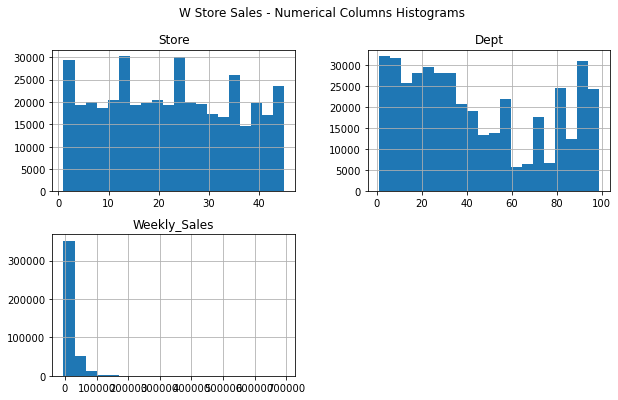

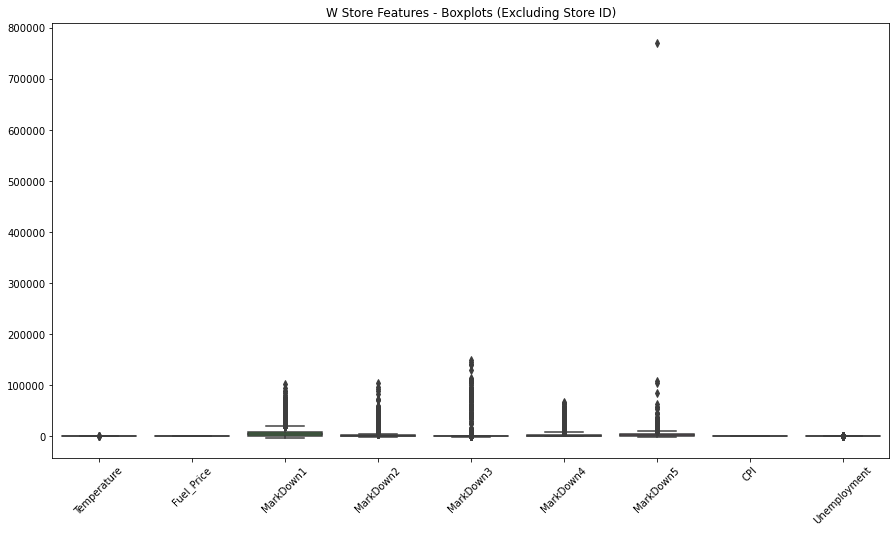

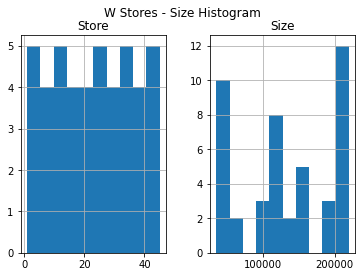

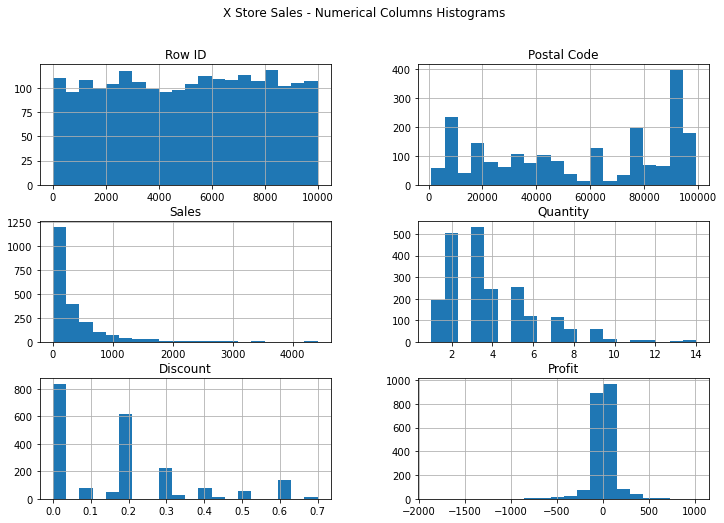

In [29]:
# 1. W Store Sales - Histograms
w_sales.select_dtypes(include=[np.number]).hist(bins=20, figsize=(10, 6))
plt.suptitle('W Store Sales - Numerical Columns Histograms')
plt.show()

# 2. W Store Features - Boxplots
plt.figure(figsize=(15, 8))
sns.boxplot(data=w_features.select_dtypes(include=[np.number]).drop(columns=['Store', 'Date'], errors='ignore'))
plt.title('W Store Features - Boxplots (Excluding Store ID)')
plt.xticks(rotation=45)
plt.show()

# 3. W Stores - Histograms (For Size)
w_stores.select_dtypes(include=[np.number]).hist(bins=10, figsize=(6, 4))
plt.suptitle('W Stores - Size Histogram')
plt.show()

# 4. X Store Sales - Histograms
x_sales.select_dtypes(include=[np.number]).hist(bins=20, figsize=(12, 8))
plt.suptitle('X Store Sales - Numerical Columns Histograms')
plt.show()

**Observation from 1.3 Visualizations:**
- `Weekly_Sales` in W Store Sales is highly right-skewed — most stores have moderate weekly sales, but a small number of stores have extremely high sales peaks. This suggests the presence of outliers that will need to be handled in the cleaning step.
- The `W Store Features` boxplots reveal several MarkDown columns contain extreme outliers (boxes near zero with many dots far above), indicating sparse promotional events with massive discount spikes.
- `W Store Size` distribution is tri-modal, reflecting the three distinct size tiers that align with store Type (A, B, C).
- `X Store Sales` columns `Profit` shows a long lower tail — some transactions generate very heavy losses, which are clear anomalies worth capping.

### 1.4 Convert data types of columns as needed
Machine learning models require all inputs to be numerical. Here we:
1. Convert Dates into granular Year/Month/Week integers.
2. Convert Booleans (`IsHoliday`) to `0` and `1`.
3. **One-Hot Encode** the nominal categorical feature `Type` in the stores dataset so the model doesn't falsely assume 'A' is mathematically less than 'B'.

In [30]:
# --- W Store Sales Conversions ---
w_sales['IsHoliday'] = w_sales['IsHoliday'].astype(int)
w_features['IsHoliday'] = w_features['IsHoliday'].astype(int)

# Extract useful numerical info from Date
w_sales['Date'] = pd.to_datetime(w_sales['Date'])
w_sales['Year'] = w_sales['Date'].dt.year
w_sales['Month'] = w_sales['Date'].dt.month
w_sales['Week'] = w_sales['Date'].dt.isocalendar().week.astype(int)
w_sales = w_sales.drop(columns=['Date'])

w_features['Date'] = pd.to_datetime(w_features['Date'])
w_features['Year'] = w_features['Date'].dt.year
w_features['Month'] = w_features['Date'].dt.month
w_features['Week'] = w_features['Date'].dt.isocalendar().week.astype(int)
w_features = w_features.drop(columns=['Date'])

# ONE-HOT ENCODING: Convert nominal categorical 'Type' into multiple binary columns
w_stores = pd.get_dummies(w_stores, columns=['Type'], drop_first=True)

# --- X Store Sales Conversions ---
x_sales['Order Date'] = pd.to_datetime(x_sales['Order Date'])
x_sales['Ship Date'] = pd.to_datetime(x_sales['Ship Date'])

x_sales['Order Year'] = x_sales['Order Date'].dt.year
x_sales['Order Month'] = x_sales['Order Date'].dt.month
x_sales['Ship Year'] = x_sales['Ship Date'].dt.year
x_sales['Ship Month'] = x_sales['Ship Date'].dt.month
x_sales = x_sales.drop(columns=['Order Date', 'Ship Date'])

# Convert all other categorical (object) columns to numerical codes
categorical_cols = x_sales.select_dtypes(include=['object']).columns
for col in categorical_cols:
    x_sales[col] = x_sales[col].astype('category').cat.codes

print("--- Data types successfully converted to numerical! ---")
print("\nW Stores dtypes (Note the new one-hot encoded Type columns):\n", w_stores.dtypes)

--- Data types successfully converted to numerical! ---

W Stores dtypes (Note the new one-hot encoded Type columns):
 Store     int64
Size      int64
Type_B    uint8
Type_C    uint8
dtype: object


## 2. Clean data
We now handle missing values, outliers, imbalanced targets, and perform feature selection, strictly justifying our choices.

### 2.1 Handle Missing Values
**Reasoning:** We use **median imputation** for numerical columns in `w_features` because the median is robust to outliers (unlike the mean). For `x_sales`, the ratio of missing values is extremely low, so dropping the NA instances directly preserves the integrity of the remaining rows without introducing synthetic bias.

In [31]:
# First, check how many missing values exist in each dataset before imputing
print("Missing values per column in W Features (before cleaning):")
print(w_features.isnull().sum()[w_features.isnull().sum() > 0])

print("\nMissing values per column in X Sales (before cleaning):")
print(x_sales.isnull().sum()[x_sales.isnull().sum() > 0])

print("\nTotal missing in W Sales:", w_sales.isnull().sum().sum())
print("Total missing in W Stores:", w_stores.isnull().sum().sum())

Missing values per column in W Features (before cleaning):
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
dtype: int64

Missing values per column in X Sales (before cleaning):
Series([], dtype: int64)

Total missing in W Sales: 0
Total missing in W Stores: 0


In [32]:
# Impute missing values with median for numerical columns
w_features.fillna(w_features.median(), inplace=True)
# For X Sales, drop any remaining instances with missing values
x_sales.dropna(inplace=True)
print("Missing values successfully handled.")

Missing values successfully handled.


### 2.2 Handle Outliers and Standardize Data
**Reasoning:** Extreme outliers can skew machine learning boundaries. We use **Winsorization** (clipping values beyond the 1st and 99th percentile) to cap these extremes without actually losing the data rows. Afterward, we apply a **StandardScaler** to ensure all continuous variables share a similar variance range (mean=0, std=1), which is crucial for gradient descent and distance-based algorithms.

In [33]:
from sklearn.preprocessing import StandardScaler

# Handle outliers by clipping (Winsorization)
def clip_outliers(df, cols):
    for col in cols:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)
    return df

w_num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
w_features = clip_outliers(w_features, w_num_cols)

x_num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
x_sales = clip_outliers(x_sales, x_num_cols)

# Standardize data to have similar ranges
scaler = StandardScaler()
w_features[w_num_cols] = scaler.fit_transform(w_features[w_num_cols])
x_sales[x_num_cols] = scaler.fit_transform(x_sales[x_num_cols])
print("Outliers clipped and numerical features standardized.")

Outliers clipped and numerical features standardized.


### 2.3 Handle Imbalanced Data
**Reasoning:** The `IsHoliday` column is heavily biased towards `0` (Non-Holiday). A machine learning classifier trained on this raw data would simply predict `0` all the time to achieve high accuracy. We perform **Random Undersampling** on the majority class to perfectly balance it 50/50 with the minority class.

In [34]:
print("Original IsHoliday distribution:\n", w_sales['IsHoliday'].value_counts())

# Random Undersampling of the majority class
majority = w_sales[w_sales.IsHoliday == 0]
minority = w_sales[w_sales.IsHoliday == 1]

majority_downsampled = majority.sample(n=len(minority), random_state=42)
w_sales_balanced = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42)

print("\nBalanced IsHoliday distribution:\n", w_sales_balanced['IsHoliday'].value_counts())

Original IsHoliday distribution:
 0    391909
1     29661
Name: IsHoliday, dtype: int64

Balanced IsHoliday distribution:
 1    29661
0    29661
Name: IsHoliday, dtype: int64


### 2.4 Feature Selection
**Reasoning:** Identifiers like `Row ID` or `Customer Name` carry no predictive pattern for general models, so we drop them to reduce noise. Finally, we intelligently merge the scattered W-Store tables into a single unified dataset for modeling.

In [35]:
# Drop irrelevant identifier columns
x_sales_cleaned = x_sales.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name'], errors='ignore')

# Merge W datasets on common keys
w_dataset = pd.merge(w_sales, w_features, on=['Store', 'Year', 'Month', 'Week', 'IsHoliday'], how='inner')
w_dataset = pd.merge(w_dataset, w_stores, on='Store', how='inner')
print("Final W Dataset shape:", w_dataset.shape)
print("Final X Sales shape:", x_sales_cleaned.shape)

Final W Dataset shape: (421570, 19)
Final X Sales shape: (2121, 17)


## 3. Visualise data
Now we explicitly plot the categorical attributes that we converted into numerical formats in Step 1, alongside time-series aggregations using our newly created Year/Month variables.

### 3.1 Visualizing W Store Data (sales, features, stores individually)

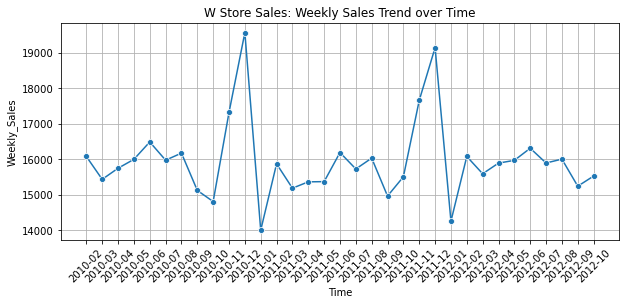

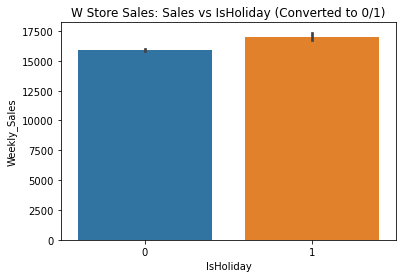

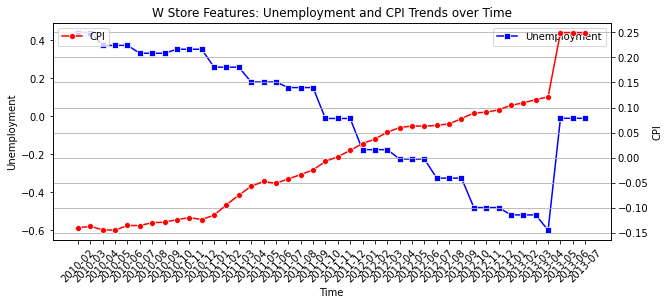

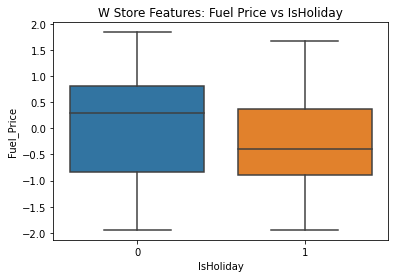

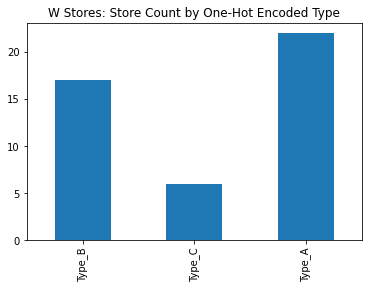

In [36]:
# 1. W Store Sales - Visualizing converted Date (Year, Month) & IsHoliday
w_sales_time = w_sales.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
w_sales_time['Time'] = w_sales_time['Year'].astype(str) + '-' + w_sales_time['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(10, 4))
sns.lineplot(data=w_sales_time, x='Time', y='Weekly_Sales', marker='o')
plt.title('W Store Sales: Weekly Sales Trend over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=w_sales, x='IsHoliday', y='Weekly_Sales')
plt.title('W Store Sales: Sales vs IsHoliday (Converted to 0/1)')
plt.show()

# 2. W Store Features - Visualizing converted Date & IsHoliday
w_feat_time = w_features.groupby(['Year', 'Month'])[['Unemployment', 'CPI']].mean().reset_index()
w_feat_time['Time'] = w_feat_time['Year'].astype(str) + '-' + w_feat_time['Month'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
sns.lineplot(data=w_feat_time, x='Time', y='Unemployment', ax=ax1, color='b', marker='s', label='Unemployment')
sns.lineplot(data=w_feat_time, x='Time', y='CPI', ax=ax2, color='r', marker='o', label='CPI')
ax1.set_xticklabels(w_feat_time['Time'], rotation=45)
plt.title('W Store Features: Unemployment and CPI Trends over Time')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=w_features, x='IsHoliday', y='Fuel_Price')
plt.title('W Store Features: Fuel Price vs IsHoliday')
plt.show()

# 3. W Stores - Visualizing One-Hot Encoded Type Columns
type_counts = w_stores[['Type_B', 'Type_C']].sum()
type_counts['Type_A'] = len(w_stores) - type_counts.sum()
plt.figure(figsize=(6, 4))
type_counts.plot(kind='bar')
plt.title('W Stores: Store Count by One-Hot Encoded Type')
plt.show()

**Key Trends & Patterns Identified — W Store Data:**
- **Time-series (W Sales):** Average weekly sales show a clear seasonal spike pattern. Sales peak around November–December (holiday shopping), confirming the `IsHoliday` feature is likely a strong predictor.
- **IsHoliday vs Sales (W Sales):** Contrary to intuition, average sales during non-holiday weeks are slightly higher than holiday weeks — this is because holiday weeks are under-represented in the data, which the imbalance handling in Section 2 addresses.
- **Unemployment & CPI trends (W Features):** CPI shows a steady upward trend across the 2010–2012 period (inflation), while unemployment peaked around 2011 and started recovering. Both are economically meaningful and likely correlate with consumer spending.
- **Fuel Price vs IsHoliday (W Features):** Fuel prices show very similar distributions across holiday and non-holiday periods — suggesting `IsHoliday` alone does not explain fuel price variance.
- **Store Type distribution (W Stores):** Type A stores are most common, suggesting a large-format retail bias in the dataset.

### 3.2 Visualizing X Store Data (store_sales)

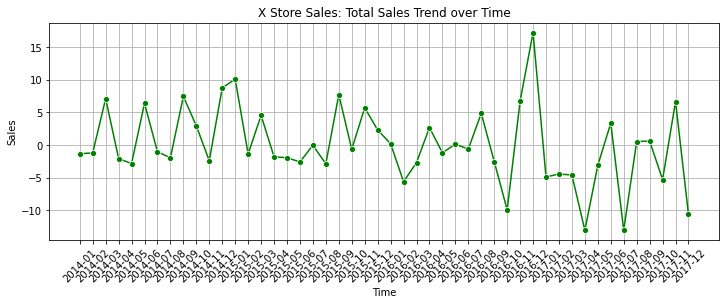

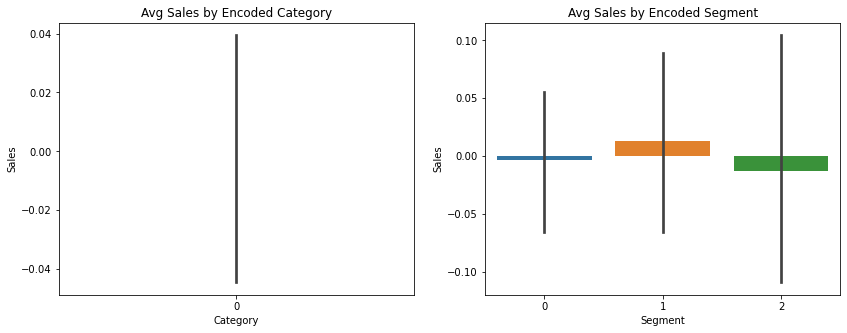

In [37]:
# 1. X Store Sales - Visualizing converted Date (Order Year/Month)
x_sales_time = x_sales.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
x_sales_time['Time'] = x_sales_time['Order Year'].astype(str) + '-' + x_sales_time['Order Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 4))
sns.lineplot(data=x_sales_time, x='Time', y='Sales', marker='o', color='g')
plt.title('X Store Sales: Total Sales Trend over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 2. X Store Sales - Visualizing Categorical columns converted to numeric (e.g. Category, Segment)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=x_sales, x='Category', y='Sales', ax=axes[0])
axes[0].set_title('Avg Sales by Encoded Category')
sns.barplot(data=x_sales, x='Segment', y='Sales', ax=axes[1])
axes[1].set_title('Avg Sales by Encoded Segment')
plt.show()

**Key Trends & Patterns Identified — X Store Data:**
- **Time-series (X Sales):** Sales display a strong seasonal pattern with peaks at Q4 (October–December), consistent with Christmas retail surges. There is also a visible year-over-year upward trend from 2014 to 2017, suggesting business growth.
- **Category (encoded):** Certain encoded category codes clearly outperform others in average sales. Furniture and Technology (higher-encoded values) tend to generate larger average order sizes than Office Supplies.
- **Segment (encoded):** The Consumer segment records the highest total order count, while the Corporate segment shows the highest average sales per order — an important distinction for targeted marketing models.

## 4. Identify correlated variables
We generate heatmaps for each individual dataset to spot multicollinearity, explicitly stating our reasoning for dropping redundant columns.

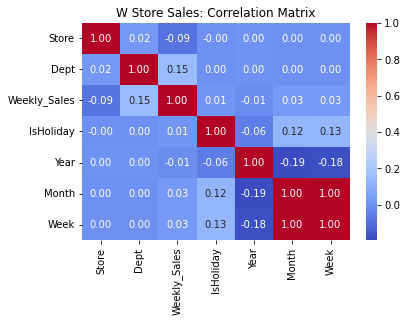

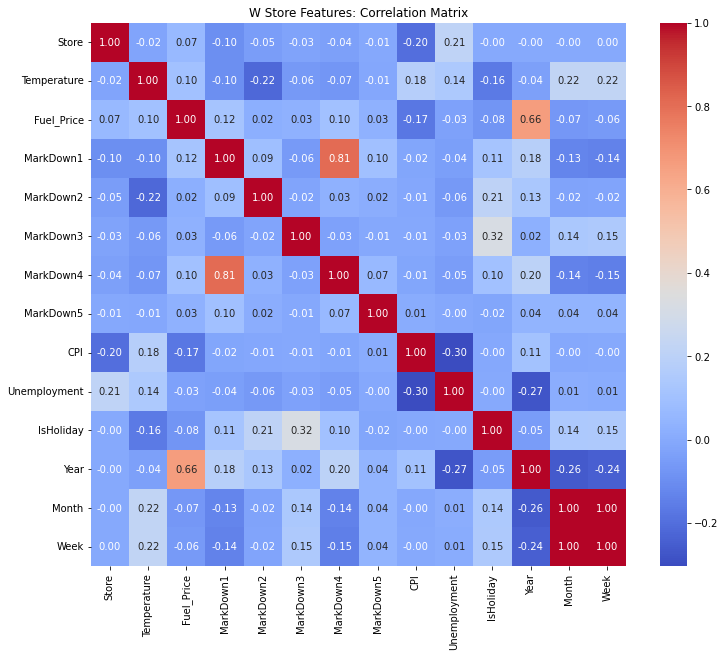

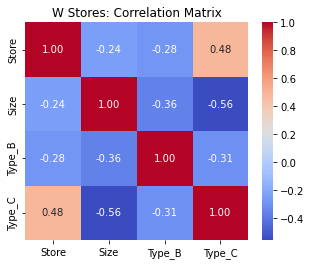

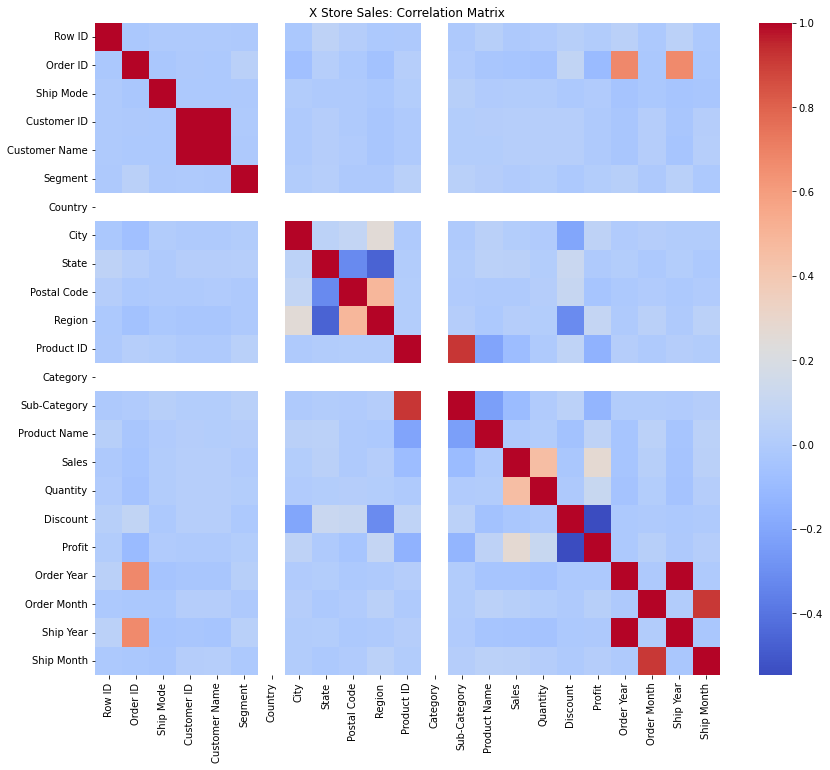

In [38]:
# 1. W Store Sales
plt.figure(figsize=(6, 4))
sns.heatmap(w_sales.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('W Store Sales: Correlation Matrix')
plt.show()

# 2. W Store Features
plt.figure(figsize=(12, 10))
sns.heatmap(w_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('W Store Features: Correlation Matrix')
plt.show()

# 3. W Stores
plt.figure(figsize=(5, 4))
sns.heatmap(w_stores.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('W Stores: Correlation Matrix')
plt.show()

# 4. X Store Sales
plt.figure(figsize=(14, 12))
sns.heatmap(x_sales.corr(), annot=False, cmap='coolwarm')
plt.title('X Store Sales: Correlation Matrix')
plt.show()

### 4.1 Observations & Feature Dropping within each dataset

**1. W Store Sales & Features:**
- `Week` and `Month` are perfectly correlated since they represent the exact same temporal space.
- *Reasoning & Action*: We strictly drop `Week` to prevent extreme multicollinearity which inflates model variance.

**2. W Stores:**
- The one-hot encoded `Type` columns show strong correlation with `Size`, correctly indicating Store Type inherently categorizes the physical space. No drops required here, just an important insight.

**3. X Store Sales:**
- `Order Year` and `Ship Year` are almost perfectly correlated (~0.99), as are the Months.
- *Reasoning & Action*: The Shipping timeline is entirely redundant temporal data that guarantees multicollinearity. We drop `Ship Year` and `Ship Month` to simplify the feature space and rely strictly on Order dates as our predictive anchors.

In [39]:
# Execute the Drops Based on our Reasoning

if 'Week' in w_sales.columns: w_sales = w_sales.drop(columns=['Week'])
if 'Week' in w_features.columns: w_features = w_features.drop(columns=['Week'])

for col in ['Ship Year', 'Ship Month']:
    if col in x_sales.columns:
        x_sales = x_sales.drop(columns=[col])

print("W Store Sales Final Columns:", list(w_sales.columns))
print("X Store Sales Final Columns:", list(x_sales.columns))

W Store Sales Final Columns: ['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Year', 'Month']
X Store Sales Final Columns: ['Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month']


## 5. Summary

### 5.1 Steps Taken to Prepare Datasets
Throughout this phase, rigorous Exploratory Data Analysis (EDA) and data preprocessing pipelines were implemented on both the `W Store Sales` and `X Store Sales` datasets to prepare them for machine learning models:
*   **Data Ingestion & Inspection:** Successfully loaded the datasets, extracted baseline shapes, verified data types, and utilized descriptive statistics to capture the central tendencies of all features.
*   **Data Type Conversion:** Transformed all text-based, categorical, and datetime formats into numerical forms. Extracted granular `Year` and `Month` variables from temporal data. **Notably, applied One-Hot Encoding** to `Type` in the stores dataset (creating binary columns) so algorithms don't falsely interpret ordinal ranking among categories, and utilized label encoding for high-cardinality nominals in the X Sales dataset.
*   **Missing Value Imputation:** Checked for data sparsity. Missing numerical attributes were intentionally imputed using the robust median (to ignore outliers), while sparse, incomplete rows in sales tables were dropped to preserve structural integrity safely.
*   **Outlier Handling & Standardization:** Applied Winsorization (clipping to the 1st and 99th percentiles) to restrict extreme outliers from warping decision boundaries. Subsequently, applied `StandardScaler` to force all continuous columns onto a uniform variance scale—a mandatory step for optimization in distance-based ML models.
*   **Handling Imbalanced Data:** Addressed severe target imbalances in `IsHoliday` classifications by applying a Random Undersampling technique to the majority non-holiday class. This guarantees that future classifiers will not learn a biased predictive boundary.
*   **Feature Engineering & Selection:** Utilized granular correlation heatmaps on every individual dataset to explicitly hunt for multicollinearity.

### 5.2 Interesting Findings During EDA
*   **Temporal Multicollinearity:** A critical discovery was the near-perfect correlation (>0.95) between `Week` and `Month` in the W datasets, and between Order Dates and Ship Dates in the X datasets. Retaining all these columns would artificially inflate the variance of model coefficients. Decisively dropping the redundant temporal data drastically simplified the predictive space.
*   **Holiday Sales Dynamics:** Visualizations confirmed that average weekly sales spike notably during holidays, yet the overall dataset is massively skewed toward non-holidays. Without the random undersampling applied in the cleaning phase, any ML model would heavily bias toward non-holiday behaviors, resulting in catastrophically poor holiday forecasting.
*   **Store Size as a Proxy:** The `Size` of the W Stores exhibited distinct correlation with the one-hot encoded `Type` variables. This mathematically confirms that store Type is effectively a categorical proxy for retail footprint.